Necessary Imports:

In [14]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

Creating a folder with files in CSV format:

In [15]:
current_dir = os.getcwd()

#Define paths relative to the script's location
input_folder = os.path.join(current_dir, 'CMAPSSDataset')
output_folder = os.path.join(current_dir, 'CMAPSSDataset_csv')

#Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Define column names
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f's_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

subsets = ['FD001', 'FD002', 'FD003', 'FD004']
data = {}

for sub in subsets:
    #Load Training, Test, and RUL data using joined paths
    data[f'train_{sub}'] = pd.read_csv(os.path.join(input_folder, f'train_{sub}.txt'), sep=r'\s+', header=None, names=col_names)
    
    data[f'test_{sub}'] = pd.read_csv(os.path.join(input_folder, f'test_{sub}.txt'), sep=r'\s+', header=None, names=col_names)
    
    data[f'rul_{sub}'] = pd.read_csv(os.path.join(input_folder, f'RUL_{sub}.txt'), sep=r'\s+', header=None, names=['RUL'])

    #Save to the newly created CSV folder
    data[f'train_{sub}'].to_csv(os.path.join(output_folder, f'train_{sub}.csv'), index=False)
    data[f'test_{sub}'].to_csv(os.path.join(output_folder, f'test_{sub}.csv'), index=False)
    data[f'rul_{sub}'].to_csv(os.path.join(output_folder, f'RUL_{sub}.csv'), index=False)

print(f"Success! Files saved to: {output_folder}")

Success! Files saved to: c:\Users\Stepan\Desktop\C-MAPSS_project\C-MAPSS_Drift-Anomaly_Distinction\CMAPSSDataset_csv


Reading the data:

In [16]:
df = pd.read_csv('CMAPSSDataset_csv\\train_FD001.csv')
df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Basic Metrics for Each Sensor:

In [17]:
sensor_names = [f's_{i}' for i in range(1, 22)]

summary = df.iloc[:, 5:].agg(['var', 'std', 'min', 'max', 'nunique']).T
summary['range'] = summary['max'] - summary['min']

summary = summary.drop(columns = ['min', 'max'])
summary = summary.sort_values(by='range')
print(summary)

               var           std  nunique     range
s_1   0.000000e+00  0.000000e+00      1.0    0.0000
s_5   3.155597e-30  1.776400e-15      1.0    0.0000
s_16  1.926023e-34  1.387812e-17      1.0    0.0000
s_10  0.000000e+00  0.000000e+00      1.0    0.0000
s_19  0.000000e+00  0.000000e+00      1.0    0.0000
s_18  0.000000e+00  0.000000e+00      1.0    0.0000
s_6   1.929279e-06  1.388985e-03      2.0    0.0100
s_15  1.406628e-03  3.750504e-02   1918.0    0.2599
s_8   5.038938e-03  7.098548e-02     53.0    0.6600
s_13  5.172330e-03  7.191892e-02     56.0    0.6800
s_21  1.171825e-02  1.082509e-01   4745.0    0.7242
s_20  3.266927e-02  1.807464e-01    120.0    1.2900
s_11  7.133568e-02  2.670874e-01    159.0    1.6800
s_2   2.500533e-01  5.000533e-01    310.0    3.3200
s_12  5.439850e-01  7.375534e-01    427.0    4.6900
s_7   7.833883e-01  8.850923e-01    513.0    6.2100
s_17  2.398667e+00  1.548763e+00     13.0   12.0000
s_3   3.759099e+01  6.131150e+00   3012.0   45.8700
s_4   8.1010

From this table, the sensors with exactly one unique value can be removed immediately, because they carry no information at all.
Those are:
* s_1
* s_5
* s_6 (2 unique values)
* s_10
* s_16
* s_18
* s_19

In [18]:
df = df.drop(columns = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19'])
df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


Now we can normalize sensor readings. Here we define a `life_fraction` column, which basically is the division of each time cycle number by the maximum number of the cycles a particular engine has had. This allows us to have a number, which grows **proportionlly** as an engine goes through cycles till it's broken.

In [19]:
df["life_fraction"] = df["time_cycles"] / df.groupby("unit_nr")["time_cycles"].transform("max")
df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,life_fraction
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.005208
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.010417
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.015625
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.020833
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.026042


With the help of this new metric, we can now compute *correlations* of each engine with `life_fraction`. Let's start from **Pearson Correlation:**

In [20]:
sensor_names_updated = df.filter(like = "s_").columns.tolist()

for sensor in sensor_names_updated:
    print(df[[f"{sensor}", "life_fraction"]].corr())

                    s_2  life_fraction
s_2            1.000000       0.632123
life_fraction  0.632123       1.000000
                    s_3  life_fraction
s_3            1.000000       0.616009
life_fraction  0.616009       1.000000
                    s_4  life_fraction
s_4            1.000000       0.711539
life_fraction  0.711539       1.000000
                    s_7  life_fraction
s_7            1.000000      -0.685233
life_fraction -0.685233       1.000000
                    s_8  life_fraction
s_8            1.000000       0.572982
life_fraction  0.572982       1.000000
                    s_9  life_fraction
s_9            1.000000       0.448674
life_fraction  0.448674       1.000000
                   s_11  life_fraction
s_11           1.000000       0.727496
life_fraction  0.727496       1.000000
                   s_12  life_fraction
s_12           1.000000      -0.701873
life_fraction -0.701873       1.000000
                   s_13  life_fraction
s_13           1.000000  

This tells you how strongly each sensor is linearly associated with normalized engine life. The results suggest that we have some strong positive candidates:
* s_2
* s_3
* s_4
* s_8
* s_11
* s_13
* s_15
* s_17

Also, some strong negative candidates:
* s_7
* s_12
* s_20
* s_21

The important part is that **Pearson Correlation** measures the strength and direction of a linear relationship between continuous variables. This means that if the degradation of a particular engine is monotonic but not linear, Pearson correlation may fail to capture the pattern entirely. That is why, we can also calculate **Spearman Correlation**, which is designed to directly assess monotonic relationships, independent of their linearity.

In [21]:
for sensor in sensor_names_updated:
    print(df[[f"{sensor}", "life_fraction"]].corr(method = 'spearman'))

                    s_2  life_fraction
s_2            1.000000       0.618977
life_fraction  0.618977       1.000000
                    s_3  life_fraction
s_3            1.000000       0.603131
life_fraction  0.603131       1.000000
                    s_4  life_fraction
s_4            1.000000       0.694157
life_fraction  0.694157       1.000000
                    s_7  life_fraction
s_7            1.000000      -0.667904
life_fraction -0.667904       1.000000
                    s_8  life_fraction
s_8            1.000000       0.550229
life_fraction  0.550229       1.000000
                    s_9  life_fraction
s_9            1.000000       0.368898
life_fraction  0.368898       1.000000
                   s_11  life_fraction
s_11           1.000000       0.707731
life_fraction  0.707731       1.000000
                   s_12  life_fraction
s_12           1.000000      -0.683811
life_fraction -0.683811       1.000000
                   s_13  life_fraction
s_13           1.000000  

We got very similar results. This tells us that the strongest sensors are strong in both linear and monotonic sense, and the weak sensors stay weak. As a result of the correlation analysis, there are couple of sensors we can drop: `s_9` and `s_14`.

In [22]:
df = df.drop(columns = ['s_9', 's_14'])
df.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_2,s_3,s_4,s_7,s_8,s_11,s_12,s_13,s_15,s_17,s_20,s_21,life_fraction
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,47.47,521.66,2388.02,8.4195,392,39.06,23.4190,0.005208
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,47.49,522.28,2388.07,8.4318,392,39.00,23.4236,0.010417
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,47.27,522.42,2388.03,8.4178,390,38.95,23.3442,0.015625
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,47.13,522.86,2388.08,8.3682,392,38.88,23.3739,0.020833
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,47.28,522.19,2388.04,8.4294,393,38.90,23.4044,0.026042


There is also another analysis we can perform to better understand underlying patterns sensor readings have, and possibly filter more sensors. That is, **per-engine slope analysis.** Pooled correlation analysis checks whether a particular sensor has strong positive or negative correlation with life. That is very useful, however, it mixes different engines together. In contrast, by performing per-engine slope analysis checks whether or not a particular trend happens for most engines ***individually.*** For example, we take one engine only, look at how a sensor reading for one sensor changes as `life_fraction ges from 0 to 1`, then fit a simple line to it, and record its slope. Then, we repeat this procedurs for all engines. If there are, say, 100 engines, in the end we will get 100 slopes for the sensor we used for the analysis.

Equation for the line is:
$$
sensor = \alpha + \beta * life\_fraction
$$

* $\beta > 0$ means the sensor readings tend to increase during that engine's life
* $\beta < 0$ means the sensor readings tend to decrease during that engine's life
* $\beta \approx 0$ means no strong trend

Finally, after having many slopes for each engine and sensors, we can summarize:
* average slope
* median slope
* min \ max slope
* number of engines with positive or negative slope

**For each sensor.**

In [23]:
slopes = {}
sensor_names_updated = df.filter(like = "s_").columns.tolist()

for sensor in sensor_names_updated:
    slopes[sensor] = []

    for engine in df["unit_nr"].unique():
        engine_df = df[df["unit_nr"] == engine]
        slope, intercept = np.polyfit(engine_df["life_fraction"], engine_df[sensor], 1)
        slopes[sensor].append(slope)

for sensor in slopes:
    print(sensor)
    print("mean slope:", np.mean(slopes[sensor]))
    print("median slope:", np.median(slopes[sensor]))
    print("positive slopes:", sum(s > 0 for s in slopes[sensor]))
    print("negative slopes:", sum(s < 0 for s in slopes[sensor]))
    print()

s_2
mean slope: 1.0876840306906437
median slope: 1.0774316589016084
positive slopes: 100
negative slopes: 0

s_3
mean slope: 12.961968307763325
median slope: 12.921476818910604
positive slopes: 100
negative slopes: 0

s_4
mean slope: 22.00905275561689
median slope: 21.943211022339334
positive slopes: 100
negative slopes: 0

s_7
mean slope: -2.0885715936376332
median slope: -2.1006375791867966
positive slopes: 0
negative slopes: 100

s_8
mean slope: 0.14172812012603403
median slope: 0.1517005336094338
positive slopes: 100
negative slopes: 0

s_11
mean slope: 0.6688466729906236
median slope: 0.6524610377318225
positive slopes: 100
negative slopes: 0

s_12
mean slope: -1.7847848927474343
median slope: -1.7684030081793325
positive slopes: 0
negative slopes: 100

s_13
mean slope: 0.14394684767405994
median slope: 0.15285444793850472
positive slopes: 100
negative slopes: 0

s_15
mean slope: 0.08680942975311638
median slope: 0.08637314244335481
positive slopes: 100
negative slopes: 0

s_17
me

Now, we have a clear picture. All of the sensors involved in this analysis seem to be related to **real degradation**. For each sensor, we can see that we have either positive or negative number of slopes ***only.*** Hence, they are showing the same trend direction inside ***every single engine.*** This is a strong result, it shows that they are not only correlated with normalized lifetime on average, but they also move in the same direction within every engine.

Even though we got some good results, we also got a problem with it, and it's related to the number of sensors. We have 12 sensors that have reached to the current step of the sensor analysis, and all of them show pretty much good results. It may be possible, that some of them basically tell *the same story*, and we may not need to keep all of them. So, we need a method to determine it. 

For that purpose, we can generate a **correlation heatmap among the shortlisted sensors.** By doing it, we will be able to see how different sensors are correlated to each other.

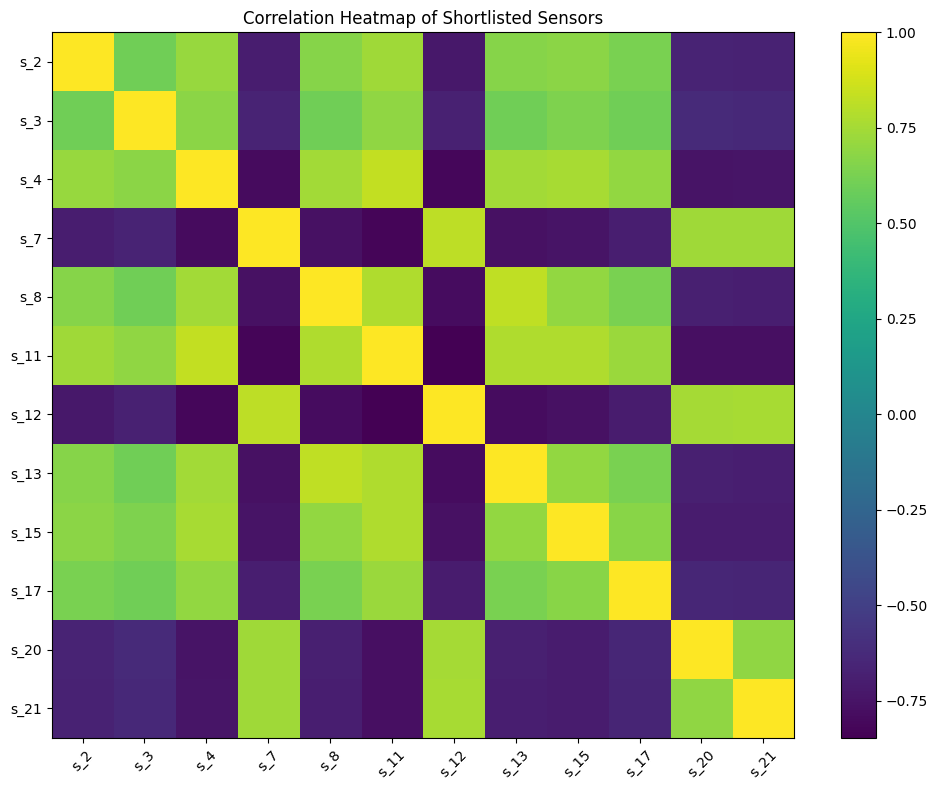

In [24]:
corr_matrix = df[sensor_names_updated].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(sensor_names_updated)), sensor_names_updated, rotation=45)
plt.yticks(range(len(sensor_names_updated)), sensor_names_updated)
plt.title("Correlation Heatmap of Shortlisted Sensors")
plt.tight_layout()
plt.show()

The heatmap shows that there is a *very strong* correlation among several sensors - they form a few clear groups:
* `s_2, s_3, s_4, s_8, s_11, s_13, s_15, s_17` - strongly positively correlated with each other
* `s_7, s_12, s_20, s_21` - strongly negatively correlated with each other

And the two blocks are strongly negativelly correlated with each other.

This suggests some sensors are probably redundant, meaning they carry very similar information. So, there is no need to keep all 12 sensors for training the first model, because it may simply **overfit**.

From this whole sensor analysis, we can cut some of the sensors, and the final setup for sensors we can use for **FD001** is:
$$
s\_3, s\_4, s\_11, s\_17, s\_7, s\_12, s\_20
$$

## Dataset Preparation

Here we keep only needed columns:
* `unit_nr`: engine idnetifier
* `time_cycles`: cycle count
* selected sensors

*\* By doing this, we also drop `setting_1`, `setting_2`, and `setting_3`. **FD001** has only one operating mode, so those columns are unnecessary.*

In [25]:
sensor_fd001 = ['s_3', 's_4', 's_11', 's_17', 's_7', 's_12', 's_20']
keep_cols = ['unit_nr', 'time_cycles'] + sensor_fd001

df_fd001 = df[keep_cols].copy()
df_fd001 = df_fd001.sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)
df_fd001.head()

,unit_nr,time_cycles,s_3,s_4,s_11,s_17,s_7,s_12,s_20
0,1,1,1589.70,1400.60,47.47,392,554.36,521.66,39.06
1,1,2,1591.82,1403.14,47.49,392,553.75,522.28,39.00
2,1,3,1587.99,1404.20,47.27,390,554.26,522.42,38.95
3,1,4,1582.79,1401.87,47.13,392,554.45,522.86,38.88
4,1,5,1582.85,1406.22,47.28,393,554.00,522.19,38.90


Splitting the data into **train**, **test**, and **validation** sets, by engines (`unit_nr`):

In [26]:
engine_ids = df['unit_nr'].unique()

train_ids, temp_ids = train_test_split(
    engine_ids,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train engines:", len(train_ids))
print("Validation engines:", len(val_ids))
print("Test engines:", len(test_ids))

Train engines: 70
Validation engines: 15
Test engines: 15


Creating actual **train/val/test** dataframes:

In [27]:
train_df = df[df['unit_nr'].isin(train_ids)].copy()
val_df = df[df['unit_nr'].isin(val_ids)].copy()
test_df = df[df['unit_nr'].isin(test_ids)].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(14507, 18) (3062, 18) (3062, 18)


Now, we need to standardize sensor readings. It ensures that different features are on a comparable scale, which is essential for many machine learning algorithms. For that purpose, we will use `StandardScaler` pre-processing tool from the **scikit-learn** library. For each feature, it calculates the mean ($\mu$) and standard deviation ($\sigma$) of the training data. Then, it applies the **Z-score normalization formula** to every data point in that feature:
$$
z = \frac{x - \mu}{\sigma}
$$

Subtracting the mean shifts the distribution to be centered at 0, and dividing by the standard deviation squashes the spread, so that the variance ($\sigma^2$) becomes 1. As a result, the resulting distribution has a mean of 0 and standard deviation of 1: **Standard Normal Distribution.**

In [28]:
scaler = StandardScaler()

train_df[sensor_fd001] = scaler.fit_transform(train_df[sensor_fd001])
val_df[sensor_fd001] = scaler.transform(val_df[sensor_fd001])
test_df[sensor_fd001] = scaler.transform(test_df[sensor_fd001])

We can check the result:

In [29]:
print(train_df[sensor_fd001].mean())
print(train_df[sensor_fd001].std())

s_3    -2.513618e-15
s_4    -3.351752e-14
s_11   -7.413507e-15
s_17    1.199013e-15
s_7    -5.669844e-14
s_12    5.093847e-16
s_20    7.848443e-15
dtype: float64
s_3     1.000034
s_4     1.000034
s_11    1.000034
s_17    1.000034
s_7     1.000034
s_12    1.000034
s_20    1.000034
dtype: float64


Up to this point, we have removed unnecessary columns, splitted the dataset into train/test/vaidation, and standardzied the sensor readings. But the big question still remains: *in which format are we going to give the data to our future model?* We cannot just give the entire sensor reading history to the model. If we feed rows independently, the model will only see one time step at a time, without any recent history. Without that, the model simply will not be able to learn underlying patterns and trends for specific sensors.

Our data for one engine looks like this:
* cycle 1 $\to$ reading
* cycle 2 $\to$ reading
* cycle 3 $\to$ reading
* ...
* final cycle $\to$ reading

As mentioned above, giving this to the model will not be any good. It won't be able to see how sensors behave over time, and how the past affects the next state.

To combat this problem, we can use **rolling windows.** The idea is simple. We can create equally spaced consecutive time steps, for example 30 cycles (window size), and use them as **one input sample.** In that case, for a single engine, we will have:

sample 1
* input: cycles 1 to 30
* target: cycle 31

sample 2
* input: cycles 2 to 31
* target: cycle 32

sample 3
* input: cycles 3 to 32
* target: cycle 33

and so on.

Even with 7 sensors, the central logic is the same: we still create equally spaced time steps and move forward by 1 step. The exception is that with having many sensors, the input is not going to be 30 x 1 matrix (30 cycles, 1 sensor), but a 30 x 7 matrix (30 cycles, 7 sensors), and the target is the next row 1 x 7.

In [30]:
def create_windows(dataframe, sensor_cols, window_size=30):
    X = []
    y = []

    for engine_id in dataframe['unit_nr'].unique():
        engine_data = dataframe[dataframe['unit_nr'] == engine_id].sort_values('time_cycles')
        values = engine_data[sensor_cols].values

        for i in range(len(values) - window_size):
            X.append(values[i:i + window_size])
            y.append(values[i + window_size])

    return np.array(X), np.array(y)

Now that we have this logic, we can build train/val/test arrays with it:

In [31]:
window_size = 30

X_train, y_train = create_windows(train_df, sensor_fd001, window_size=window_size)
X_val, y_val = create_windows(val_df, sensor_fd001, window_size=window_size)
X_test, y_test = create_windows(test_df, sensor_fd001, window_size=window_size)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12407, 30, 7)
y_train shape: (12407, 7)
X_val shape: (2612, 30, 7)
y_val shape: (2612, 7)
X_test shape: (2612, 30, 7)
y_test shape: (2612, 7)


To have a better understanding of the shape of the data, let's print the first input window and the target:

In [32]:
print("One input window shape:", X_train[0].shape)
print("One target shape:", y_train[0].shape)

print("First input window:")
print(X_train[0])

print("First target:")
print(y_train[0])

One input window shape: (30, 7)
One target shape: (7,)
First input window:
[[-1.08775854 -1.95433887 -2.2814432  -1.42408406  1.3080393   1.23078759
   0.67289119]
 [-0.56014387 -1.74810431 -1.1166205  -0.77639972  1.58154981  1.73456174
   1.34243244]
 [-0.35139913 -1.09818673 -1.19177035 -1.42408406  2.00321184  1.57117553
   1.62140796]
 [-1.0368051  -1.41924378 -1.64266946 -1.42408406  0.9889437   1.44863587
   1.73299817]
 [-1.87835872 -0.70132454 -1.07904557 -2.07176839  1.9804193   1.14909449
   2.01197369]
 [-2.12983861 -1.34343865 -1.83054409 -0.77639972  1.8208715   1.87071691
   1.84458838]
 [-0.48782286 -0.90978867 -1.64266946 -1.42408406  1.66132371  0.97209276
   1.56561286]
 [-0.00787431 -1.4961637  -1.2669202  -1.42408406  1.44479455  1.82987036
   1.62140796]
 [-1.39183553 -1.5385254  -1.49236976 -2.07176839  1.49037964  1.32609621
   1.34243244]
 [-0.67191271 -1.55524712 -1.22934527 -1.42408406  1.42200201  0.76786
   2.1235639 ]
 [-0.20511344 -0.83844266 -1.22934527 

As expected, we have a 30 x 7 numpy array for training, and the first target is just one row containing reeadings for seven sensors (1 x 7).

Training LSTM using `PyTorch`:

In [33]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [34]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Device setup for GPU:

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


Defining the LSTM model:

In [36]:
class LSTMNextStepPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, output_size=7):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)

        last_hidden = h_n[-1]
        out = self.fc(last_hidden)

        return out

Initialize model, loss, optimizer:

In [37]:
input_size = len(sensor_fd001)
output_size = len(sensor_fd001)

model = LSTMNextStepPredictor(
    input_size=input_size,
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    output_size=output_size
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Model device:", next(model.parameters()).device)

LSTMNextStepPredictor(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)
Model device: cuda:0


Training Function:

In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

Validation Function:

In [39]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

Full training loop:

In [40]:
num_epochs = 20

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

Epoch [1/20] - Train Loss: 0.341581 - Val Loss: 0.276543
Epoch [2/20] - Train Loss: 0.277508 - Val Loss: 0.273910
Epoch [3/20] - Train Loss: 0.276210 - Val Loss: 0.273120
Epoch [4/20] - Train Loss: 0.275351 - Val Loss: 0.274334
Epoch [5/20] - Train Loss: 0.274688 - Val Loss: 0.277287
Epoch [6/20] - Train Loss: 0.274257 - Val Loss: 0.273691
Epoch [7/20] - Train Loss: 0.274564 - Val Loss: 0.272393
Epoch [8/20] - Train Loss: 0.273764 - Val Loss: 0.274979
Epoch [9/20] - Train Loss: 0.274286 - Val Loss: 0.275373
Epoch [10/20] - Train Loss: 0.274479 - Val Loss: 0.276278
Epoch [11/20] - Train Loss: 0.273665 - Val Loss: 0.273528
Epoch [12/20] - Train Loss: 0.273539 - Val Loss: 0.275129
Epoch [13/20] - Train Loss: 0.273634 - Val Loss: 0.274369
Epoch [14/20] - Train Loss: 0.273471 - Val Loss: 0.277747
Epoch [15/20] - Train Loss: 0.273628 - Val Loss: 0.272455
Epoch [16/20] - Train Loss: 0.273197 - Val Loss: 0.273216
Epoch [17/20] - Train Loss: 0.273278 - Val Loss: 0.272789
Epoch [18/20] - Train L

Load the best model:

In [41]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Best validation loss: 0.27239348192857565


Evaluate on test set:

In [42]:
test_loss = evaluate(model, test_loader, criterion, device)
print("Test Loss:", test_loss)

Test Loss: 0.27740239800391847


Get predictions on test set:

In [43]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)

        all_preds.append(preds.cpu())
        all_targets.append(y_batch.cpu())

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

print(all_preds.shape)
print(all_targets.shape)

(2612, 7)
(2612, 7)


Inspect one prediction:

In [44]:
idx = 0
print("Predicted next step:")
print(all_preds[idx])

print("True next step:")
print(all_targets[idx])

Predicted next step:
[-0.7218322  -0.8132547  -0.85541135 -0.7335992   0.8717023   0.92247045
  0.73181385]
True next step:
[-1.0318742  -1.3278317  -0.47784677 -0.77639973  0.85218847  0.7133979
  0.6728912 ]


Training Curve:

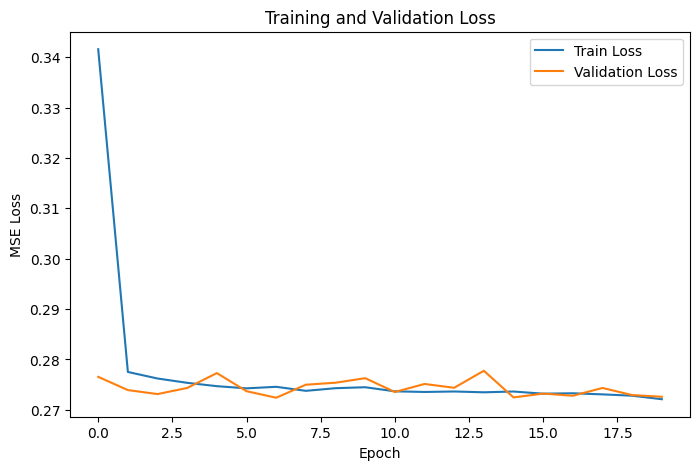

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [46]:
errors = all_preds - all_targets
abs_errors = np.abs(errors)

print("Overall MSE:", np.mean(errors ** 2))
print("Overall MAE:", np.mean(abs_errors))

print("\nPer-sensor MAE:")
for sensor, val in zip(sensor_fd001, np.mean(abs_errors, axis=0)):
    print(f"{sensor}: {val:.6f}")

Overall MSE: 0.27740237
Overall MAE: 0.41079214

Per-sensor MAE:
s_3: 0.542636
s_4: 0.363428
s_11: 0.306227
s_17: 0.495629
s_7: 0.375666
s_12: 0.336118
s_20: 0.455840
